In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [2]:

def golden_section_search(x0, y0, f, a, b, tolerance=1e-7):    
	phi = (1 + math.sqrt(5)) / 2
	resphi = 2 - phi
	x1 = a + resphi * (b - a)
	x2 = b - resphi * (b - a)
 
	def dist_sq(x): 
		return (x - x0)**2 + (f(x) - y0)**2
 
	f_x1 = dist_sq(x1)
	f_x2 = dist_sq(x2)
 
	iterations = []
 
	while abs(b - a) > tolerance:
		iterations.append((a, b))
     
		if f_x1 < f_x2:
			b = x2
			x2 = x1
			f_x2 = f_x1
			x1 = a + resphi * (b - a)
			f_x1 = dist_sq(x1)
		else:
			a = x1
			x1 = x2
			f_x1 = f_x2
			x2 = b - resphi * (b - a)
			f_x2 = dist_sq(x2)
   
	best_x = (a + b) / 2

	return math.sqrt(dist_sq(best_x)), best_x, iterations


In [3]:
x0 = -8
y0 = 0

f = lambda x : x**2 + 5

a = -5
b = 5

shortest_distance, closest_x, iterations = golden_section_search(x0, y0, f, a, b)

print("Iterations:", iterations)
print("Closest x:", closest_x)
print("Closest point on the curve: (", closest_x, ",", f(closest_x), ")")
print("Shortest distance:", shortest_distance)

Iterations: [(-5, 5), (-5, 1.180339887498949), (-2.6393202250021033, 1.180339887498949), (-1.180339887498949, 1.180339887498949), (-1.180339887498949, 0.27864045000420634), (-1.180339887498949, -0.2786404500042057), (-0.8359213500126185, -0.2786404500042057), (-0.8359213500126185, -0.4915028125262878), (-0.8359213500126185, -0.6230589874905367), (-0.754615162454785, -0.6230589874905367), (-0.7043651750483699, -0.6230589874905367), (-0.7043651750483699, -0.6541151876419552), (-0.6851713877933737, -0.6541151876419552), (-0.6851713877933737, -0.6659776005383774), (-0.6778400134347997, -0.6659776005383774), (-0.6778400134347997, -0.6705086390762256), (-0.6750396776140739, -0.6705086390762256), (-0.6733089748969515, -0.6705086390762256), (-0.6733089748969515, -0.671578272179829), (-0.6726479052834325, -0.671578272179829), (-0.672239341793348, -0.671578272179829), (-0.672239341793348, -0.6718307783032635), (-0.672239341793348, -0.6719868356699136), (-0.6721428930365635, -0.6719868356699136),

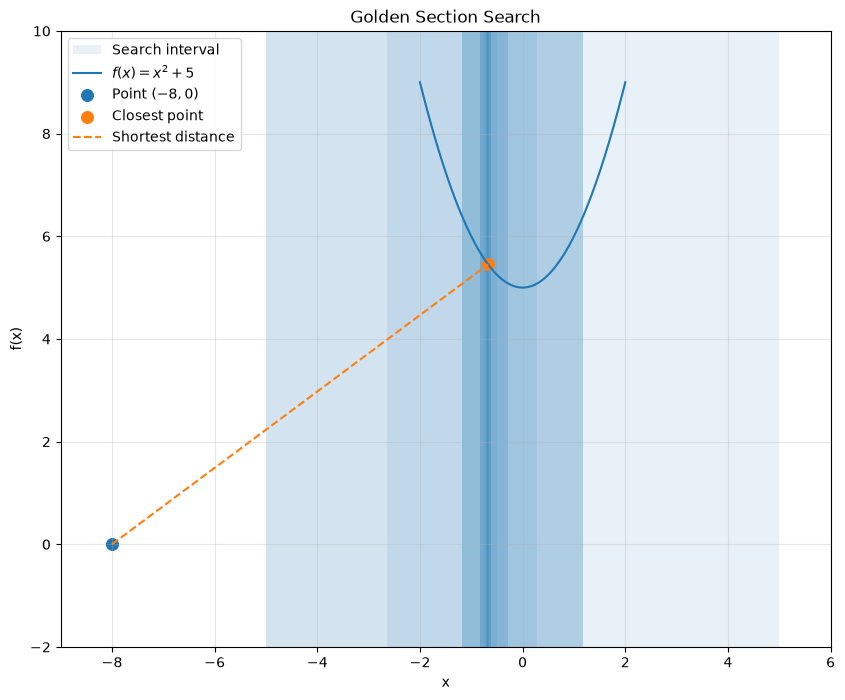

In [4]:
closest_y = f(closest_x)

x_values = np.linspace(-2, 2, 500)

plt.figure(figsize=(10, 8))

# Show the shrinking intervals
for i, (a, b) in enumerate(iterations):
    plt.axvspan(
        a, b,
        alpha=0.10,
        label="Search interval" if i == 0 else None
    )

# Plot parabola
plt.plot(x_values, f(x_values), label=r"$f(x)=x^2+5$")

# Original point
plt.scatter(x0, y0, s=70, label="Point $(-8,0)$")

# Closest point
plt.scatter(
    closest_x,
    closest_y,
    s=70,
    label="Closest point"
)

# Line showing shortest distance
plt.plot(
    [x0, closest_x],
    [y0, closest_y],
    "--",
    label="Shortest distance"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Golden Section Search")

plt.xlim(-9, 6)
plt.ylim(-2, 10)

plt.gca().set_aspect("equal", adjustable="box")

plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(
    "media/golden.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
x0 = -1
y0 = 5

f = lambda x : 2 * x**3 + x**2 - 3 * x + 7

a = -5
b = 5

shortest_distance, closest_x, iterations = golden_section_search(x0, y0, f, a, b)

print("Iterations:", iterations)
print("Closest x:", closest_x)
print("Closest point on the curve: (", closest_x, ",", f(closest_x), ")")
print("Shortest distance:", shortest_distance)

Iterations: [(-5, 5), (-5, 1.180339887498949), (-2.6393202250021033, 1.180339887498949), (-1.180339887498949, 1.180339887498949), (-0.2786404500042057, 1.180339887498949), (-0.2786404500042057, 0.6230589874905369), (0.0657780874821246, 0.6230589874905369), (0.27864045000420634, 0.6230589874905369), (0.27864045000420634, 0.4915028125262884), (0.3599466375620399, 0.4915028125262884), (0.3599466375620399, 0.44125282511987346), (0.3599466375620399, 0.410196624968455), (0.37914042481703625, 0.410196624968455), (0.3910028377134585, 0.410196624968455), (0.3910028377134585, 0.4028652506098809), (0.3910028377134585, 0.3983342120720327), (0.39380317353418437, 0.3983342120720327), (0.39380317353418437, 0.39660350935491023), (0.39380317353418437, 0.39553387625130676), (0.39446424314770334, 0.39553387625130676), (0.39446424314770334, 0.3951253127612223), (0.3947167492711378, 0.3951253127612223), (0.3947167492711378, 0.39496925539457234), (0.3948131980279223, 0.39496925539457234), (0.394872806637787

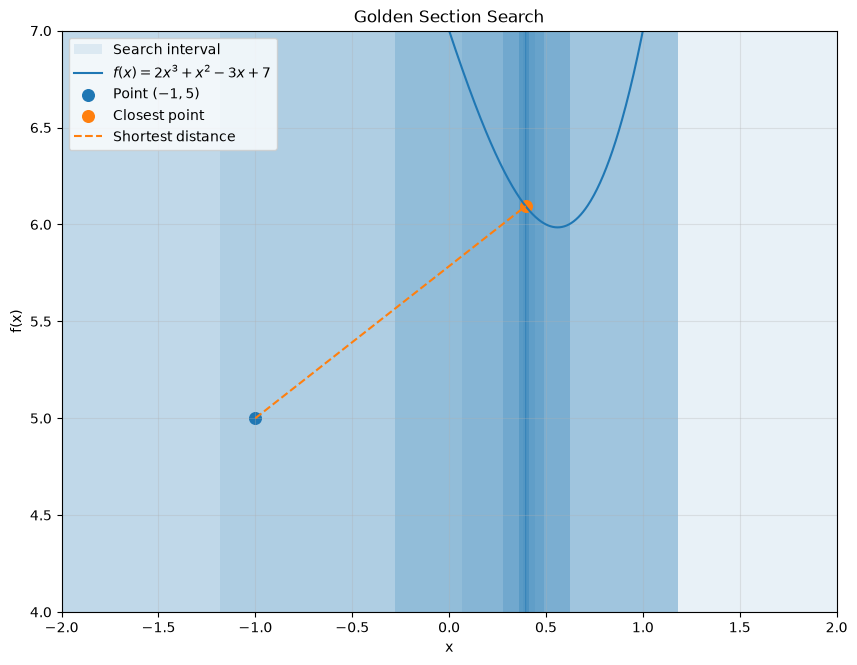

In [6]:
closest_y = f(closest_x)

x_values = np.linspace(-1, 1, 500)

plt.figure(figsize=(10, 8))

# Show the shrinking intervals
for i, (a, b) in enumerate(iterations):
    plt.axvspan(
        a, b,
        alpha=0.10,
        label="Search interval" if i == 0 else None
    )

# Plot parabola
plt.plot(x_values, f(x_values), label=r"$f(x)=2x^3 + x^2 - 3x + 7$")

# Original point
plt.scatter(x0, y0, s=70, label="Point $(-1,5)$")

# Closest point
plt.scatter(
    closest_x,
    closest_y,
    s=70,
    label="Closest point"
)

# Line showing shortest distance
plt.plot(
    [x0, closest_x],
    [y0, closest_y],
    "--",
    label="Shortest distance"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Golden Section Search")

plt.xlim(-2, 2)
plt.ylim(4, 7)

plt.gca().set_aspect("equal", adjustable="box")

plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(
    "media/golden-oth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
x0 = 2
y0 = 3

f = lambda x : 2**x + 2

a = -5
b = 5

shortest_distance, closest_x, iterations = golden_section_search(x0, y0, f, a, b)

print("Iterations:", iterations)
print("Closest x:", closest_x)
print("Closest point on the curve: (", closest_x, ",", f(closest_x), ")")
print("Shortest distance:", shortest_distance)

Iterations: [(-5, 5), (-1.180339887498949, 5), (-1.180339887498949, 2.6393202250021033), (0.2786404500042057, 2.6393202250021033), (0.2786404500042057, 1.7376207875073608), (0.2786404500042057, 1.180339887498949), (0.6230589874905362, 1.180339887498949), (0.6230589874905362, 0.9674775249768669), (0.7546151624547848, 0.9674775249768669), (0.8359213500126179, 0.9674775249768669), (0.8359213500126179, 0.9172275375704517), (0.8669775501640367, 0.9172275375704517), (0.8861713374190333, 0.9172275375704517), (0.8861713374190333, 0.9053651246740295), (0.8861713374190333, 0.8980337503154554), (0.8907023759568815, 0.8980337503154554), (0.8907023759568815, 0.8952334144947296), (0.8924330786740039, 0.8952334144947296), (0.8935027117776073, 0.8952334144947296), (0.8935027117776073, 0.8945723448812107), (0.8939112752676918, 0.8945723448812107), (0.8939112752676918, 0.8943198387577762), (0.8940673326343418, 0.8943198387577762), (0.8940673326343418, 0.8942233900009917), (0.8940673326343418, 0.89416378

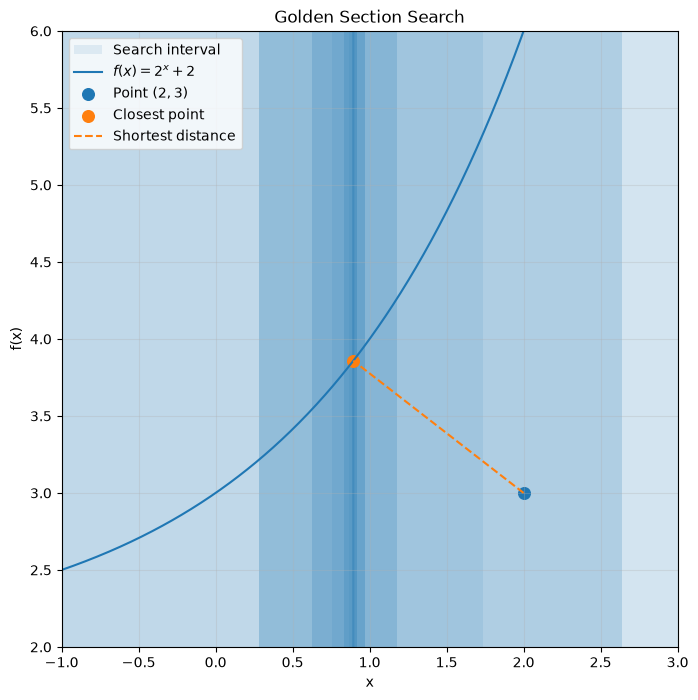

In [8]:
closest_y = f(closest_x)

x_values = np.linspace(-1, 2.5, 500)

plt.figure(figsize=(10, 8))

# Show the shrinking intervals
for i, (a, b) in enumerate(iterations):
    plt.axvspan(
        a, b,
        alpha=0.10,
        label="Search interval" if i == 0 else None
    )

# Plot parabola
plt.plot(x_values, f(x_values), label=r"$f(x)=2^x + 2$")

# Original point
plt.scatter(x0, y0, s=70, label="Point $(2,3)$")

# Closest point
plt.scatter(
    closest_x,
    closest_y,
    s=70,
    label="Closest point"
)

# Line showing shortest distance
plt.plot(
    [x0, closest_x],
    [y0, closest_y],
    "--",
    label="Shortest distance"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Golden Section Search")

plt.xlim(-1, 3)
plt.ylim(2, 6)

plt.gca().set_aspect("equal", adjustable="box")

plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(
    "media/golden-exp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()